## Neural Network Model
This notebook builds and evaluates a feedforward neural network in TensorFlow/Keras for the credit default classification task, to compare against the Logistic Regression and Random Forest baselines established in baseline_model.ipynb. The goal isn't just to build a working neural network, but to determine whether the added complexity of a deep learning approach provides a meaningful performance improvement over simpler models for this particular problem. The same preprocessing pipeline, train/val/test splits, and evaluation functions from earlier notebooks are reused here, so all three models are compared on equal footing.

In [ ]:
import sys
sys.path.append("..")

import numpy as np
from src.data_loader import load_raw_data
from src.preprocessing import run_preprocessing_pipeline
from src.evaluate import evaluate_classifier, plot_confusion_matrix, plot_roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

df = load_raw_data()
splits, artifacts = run_preprocessing_pipeline(df)

# Compute class weights the same way sklearn's class_weight='balanced' does,
# so both baselines and the NN handle imbalance under the same logic.
class_weights = compute_class_weight(
    'balanced', classes=np.unique(splits.y_train), y=splits.y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

model = keras.Sequential([
    layers.Input(shape=(splits.X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model.fit(
    splits.X_train, splits.y_train,
    validation_data=(splits.X_val, splits.y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=2
)

Loaded data via local (30000 rows, 25 columns).
Class weights: {0: np.float64(0.6420447596918185), 1: np.float64(2.260008609556608)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
83/83 - 1s - 14ms/step - auc: 0.6700 - loss: 0.6493 - val_auc: 0.7505 - val_loss: 0.6019
Epoch 2/50
83/83 - 0s - 974us/step - auc: 0.7362 - loss: 0.6084 - val_auc: 0.7620 - val_loss: 0.5790
Epoch 3/50
83/83 - 0s - 906us/step - auc: 0.7483 - loss: 0.5981 - val_auc: 0.7675 - val_loss: 0.5699
Epoch 4/50
83/83 - 0s - 926us/step - auc: 0.7544 - loss: 0.5910 - val_auc: 0.7713 - val_loss: 0.5561
Epoch 5/50
83/83 - 0s - 941us/step - auc: 0.7610 - loss: 0.5844 - val_auc: 0.7725 - val_loss: 0.5708
Epoch 6/50
83/83 - 0s - 900us/step - auc: 0.7594 - loss: 0.5839 - val_auc: 0.7740 - val_loss: 0.5675
Epoch 7/50
83/83 - 0s - 924us/step - auc: 0.7633 - loss: 0.5814 - val_auc: 0.7752 - val_loss: 0.5633
Epoch 8/50
83/83 - 0s - 935us/step - auc: 0.7669 - loss: 0.5799 - val_auc: 0.7756 - val_loss: 0.5582
Epoch 9/50
83/83 - 0s - 898us/step - auc: 0.7666 - loss: 0.5780 - val_auc: 0.7765 - val_loss: 0.5630


### Evaluate

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step
=== Neural Network (val) ===
Precision: 0.4552  (of predicted defaulters, how many actually defaulted)
Recall:    0.6171  (of actual defaulters, how many did we catch)
F1:        0.5239  (harmonic mean of precision and recall)
ROC-AUC:   0.7713  (ranking quality across all thresholds)

              precision    recall  f1-score   support

  No Default       0.88      0.79      0.83      3505
     Default       0.46      0.62      0.52       995

    accuracy                           0.75      4500
   macro avg       0.67      0.70      0.68      4500
weighted avg       0.79      0.75      0.76      4500



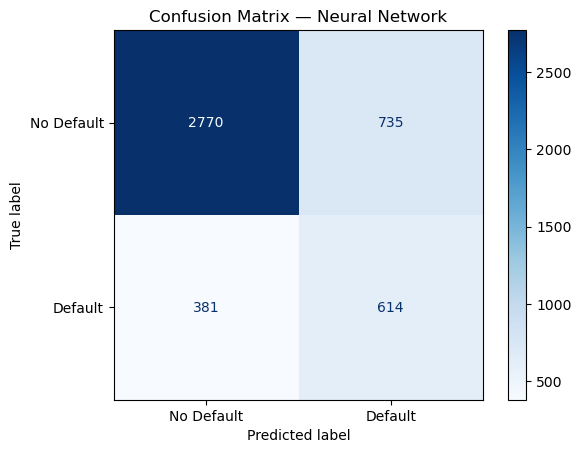

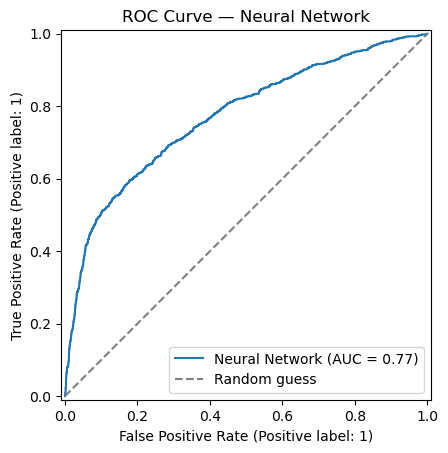

In [2]:
y_pred_proba_nn = model.predict(splits.X_val).ravel()
y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int)

results_nn = evaluate_classifier(splits.y_val, y_pred_nn, y_pred_proba_nn, model_name="Neural Network (val)")
plot_confusion_matrix(splits.y_val, y_pred_nn, model_name="Neural Network")
plot_roc_curve(splits.y_val, y_pred_proba_nn, model_name="Neural Network")

The neural network achieved a ROC-AUC of 0.7713, precision of 0.46, recall of 0.62, and F1 of 0.52 — essentially matching Logistic Regression's F1 (0.52) and Random Forest's ROC-AUC (0.7716), despite being a considerably more complex model. This is not a failure of implementation; it's a genuine and well-documented finding on tabular data of this size and structure: with 23 features and ~21,000 training rows, the extractable signal is largely linear or simple enough that Logistic Regression already captures most of it, and neural networks don't reliably outperform simpler models the way they do on unstructured data like images or text. Training itself was well-behaved — validation loss converged within 4 epochs before Early Stopping halted training at epoch 9, with no signs of instability or runaway overfitting.

Rather than treating this as a shortcoming, this result is documented as evidence of the model comparison working as intended: it shows that model complexity should be justified by measurable performance gains, not assumed. The next step is a lightweight hyperparameter tuning pass to confirm whether this plateau holds across reasonable architecture variations, followed by a final three-model comparison summary.